# Problema del Paracaidista :)

## Ecuación de movimiento

Aplicando la segunda ley de Newton:

$$
m\frac{dv}{dt} = mg - kv
$$

o

$$
\frac{dv}{dt} = g - \frac{k}{m}v
$$

---

## Ecuación de posición

La altura disminuye mientras cae:

$$
\frac{dx}{dt} = -v
$$

con condiciones iniciales:

$$
v(0)=0, \quad x(0)=h_0
$$

---

## Método numérico

Se usa el método de Euler:

$$
v_{n+1}=v_n+\Delta t\left(g-\frac{k}{m}v_n\right)
$$

$$
x_{n+1}=x_n-\Delta t\,v_n
$$

Tiempo de impacto: 70.20 s
Velocidad al impactar: 62.78 m/s

Archivo guardado como: teorico.dat


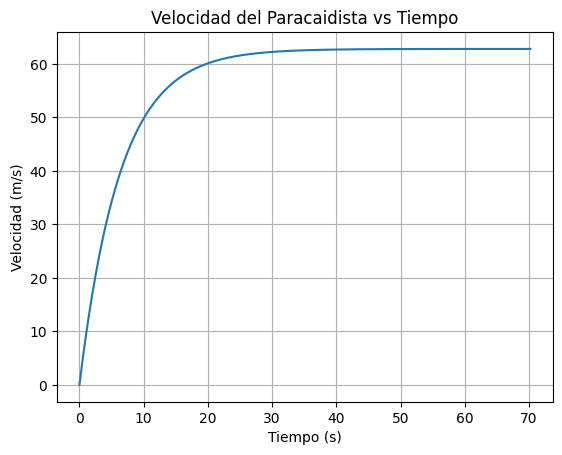

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Parámetros físicos
# -----------------------------
m = 80.0        # masa (kg)
g = 9.81        # gravedad (m/s^2)
k = 12.5        # coeficiente de arrastre
h0 = 4000.0     # altura inicial (m)

# -----------------------------
# Parámetros numéricos
# -----------------------------
dt = 0.1

# Listas dinámicas (ya no usamos tiempo fijo)
t = [0.0]
v = [0.0]       # velocidad positiva hacia abajo
x = [h0]        # altura

# -----------------------------
# Método de Euler
# -----------------------------
while x[-1] > 0:

    dvdt = g - (k/m)*v[-1]
    dxdt = -v[-1]

    v_new = v[-1] + dvdt*dt
    x_new = x[-1] + dxdt*dt
    t_new = t[-1] + dt

    v.append(v_new)
    x.append(x_new)
    t.append(t_new)

# Convertir a arrays
t = np.array(t)
x = np.array(x)
v = np.array(v)

print(f"Tiempo de impacto: {t[-1]:.2f} s")
print(f"Velocidad al impactar: {v[-1]:.2f} m/s")

# -----------------------------
# Guardar archivo .dat alineado
# -----------------------------
nombre_archivo = "teorico.dat"

with open(nombre_archivo, "w") as f:

    f.write(f"{'Tiempo (s)':>15} {'Altura (m)':>20} {'Velocidad (m/s)':>20}\n")

    for ti, xi, vi in zip(t, x, v):
        f.write(f"{ti:15.5f} {xi:20.8f} {vi:20.8f}\n")

print(f"\nArchivo guardado como: {nombre_archivo}")

# -----------------------------
# Gráfica velocidad
# -----------------------------
plt.figure()
plt.plot(t, v)
plt.xlabel("Tiempo (s)")
plt.ylabel("Velocidad (m/s)")
plt.title("Velocidad del Paracaidista vs Tiempo")
plt.grid()
plt.show()

## Entrenamiento de Redes Neuronales para Regresión

A continuación, utilizaremos los datos generados anteriormente para entrenar tres arquitecturas de redes neuronales distintas. El objetivo es predecir la **velocidad ($v$)** en función del **tiempo ($t$)**.

Pasos que realizaremos:
1. Preparación y normalización de los datos.
2. Definición de 3 arquitecturas (2, 3 y 4 capas).
3. Entrenamiento midiendo el tiempo de ejecución de cada una.
4. Visualización de resultados y comparativa de rendimiento.

In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# 1. Preparación de datos (usando las variables t y v de tu celda anterior)
# Reajustamos la forma para que Keras los procese (matrices columna)
X = t.reshape(-1, 1)
y = v.reshape(-1, 1)

# Normalización: Es vital para que la red converja rápido
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y)

# División en entrenamiento y validación
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.2, random_state=42)

print(f"Datos preparados. Formato de entrada: {X_train.shape}")

I0000 00:00:1773617920.659192 1474040 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Datos preparados. Formato de entrada: (562, 1)


Arquitectura de 2 capas:  Capa de entrada, 2 capas ocultas de 16 neuronas cada una y una cada de salida.
    (Puede sufrir underfitting)

Arquitectura de 3 capas:  3 capas ocultas, la primera de 64, la segunda de 32 y la tercera de 16.

Arquitectua de 4 capas: 4 capas ocultas, la primera de 128, la segunda de 64, la tercera de 32 y la ultima de 16 


El entrenemiento fue 80 - 20

In [3]:
# Definición de las 3 arquitecturas solicitadas
def obtener_modelos():
    # Arquitectura 1: 2 capas ocultas (Pequeña)
    m1 = keras.Sequential([
        layers.Dense(16, activation='relu', input_shape=(1,)),
        layers.Dense(16, activation='relu'),
        layers.Dense(1) # Salida lineal para regresión
    ])
    
    # Arquitectura 2: 3 capas ocultas (Mediana)
    m2 = keras.Sequential([
        layers.Dense(64, activation='relu', input_shape=(1,)),
        layers.Dense(32, activation='relu'),
        layers.Dense(16, activation='relu'),
        layers.Dense(1)
    ])
    
    # Arquitectura 3: 4 capas ocultas (Grande/Profunda)
    m3 = keras.Sequential([
        layers.Dense(128, activation='relu', input_shape=(1,)),
        layers.Dense(64, activation='relu'),
        layers.Dense(32, activation='relu'),
        layers.Dense(16, activation='relu'),
        layers.Dense(1)
    ])
    
    modelos = [m1, m2, m3]
    nombres = ["2 Capas (Pequeña)", "3 Capas (Mediana)", "4 Capas (Grande)"]
    
    for m in modelos:
        m.compile(optimizer='adam', loss='mse', metrics=['mae'])
        
    return modelos, nombres

modelos, nombres = obtener_modelos()
historiales = []
tiempos = []

# Proceso de entrenamiento y medición de tiempo
for i in range(len(modelos)):
    print(f"Entrenando {nombres[i]}...")
    
    inicio = time.time()
    history = modelos[i].fit(
        X_train, y_train,
        epochs=100,
        batch_size=32,
        validation_split=0.2,
        verbose=0 # No mostramos logs para limpiar la salida
    )
    fin = time.time()
    
    duracion = fin - inicio
    tiempos.append(duracion)
    historiales.append(history)
    print(f"Completado en {duracion:.2f} segundos.")

print("\n--- Entrenamiento finalizado ---")

/home/sergio/Documentos/Entornos/tf_gpu/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1773617924.441432 1474040 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1054 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Ti, pci bus id: 0000:07:00.0, compute capability: 8.9


Entrenando 2 Capas (Pequeña)...


I0000 00:00:1773617925.447209 1474127 service.cc:153] XLA service 0x7f7bf4030870 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1773617925.447222 1474127 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4060 Ti, Compute Capability 8.9 (Driver: 13.0.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.20.0)
I0000 00:00:1773617925.460528 1474127 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1773617925.538326 1474127 cuda_dnn.cc:461] Loaded cuDNN version 92000
I0000 00:00:1773617925.542989 1474127 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1480__.9
I0000 00:00:1773617926.136445 1474127 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Completado en 9.08 segundos.
Entrenando 3 Capas (Mediana)...


I0000 00:00:1773617934.855544 1474124 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_13143__.10


Completado en 9.75 segundos.
Entrenando 4 Capas (Grande)...


I0000 00:00:1773617944.607553 1474127 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_25103__.11
I0000 00:00:1773617944.616001 1474127 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1773617944.927277 1488811 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_22', 76 bytes spill stores, 76 bytes spill loads

I0000 00:00:1773617944.963696 1474127 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1773617945.234697 1488813 subprocess_compilation.cc:348] ptxas warning : Registers are spille

Completado en 11.22 segundos.

--- Entrenamiento finalizado ---


## Resultados y Comparativa

Analizaremos el desempeño mediante dos gráficas:
1. **Curvas de Error (Loss):** Para ver qué tan rápido aprendió cada red.
2. **Tiempos de Ejecución:** Para comparar el costo computacional de cada arquitectura.

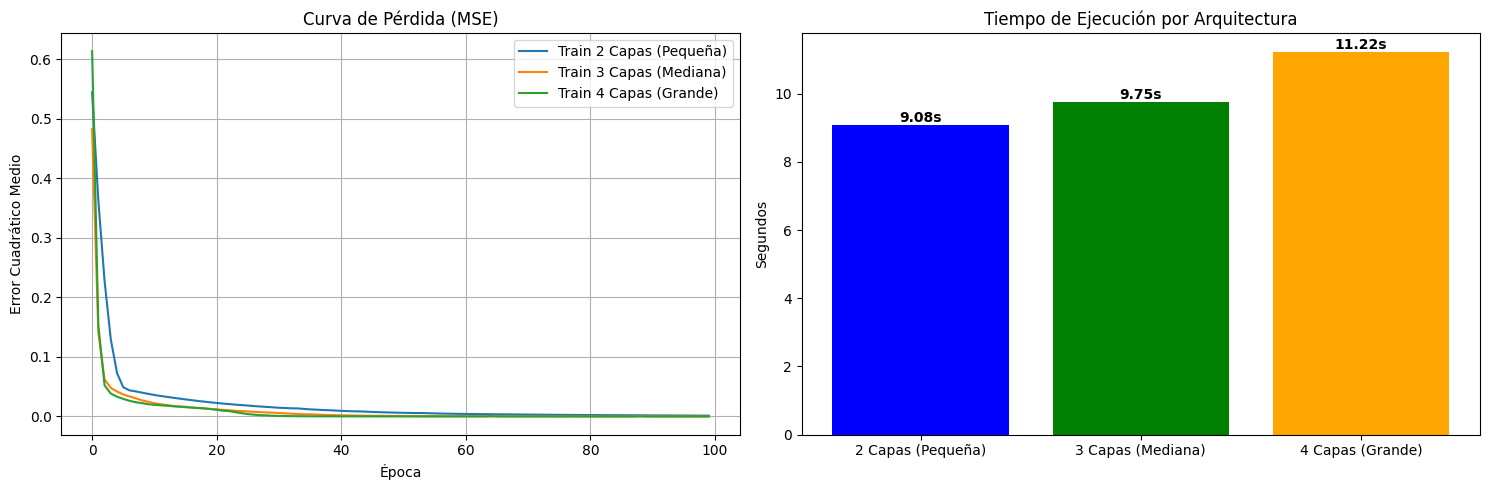

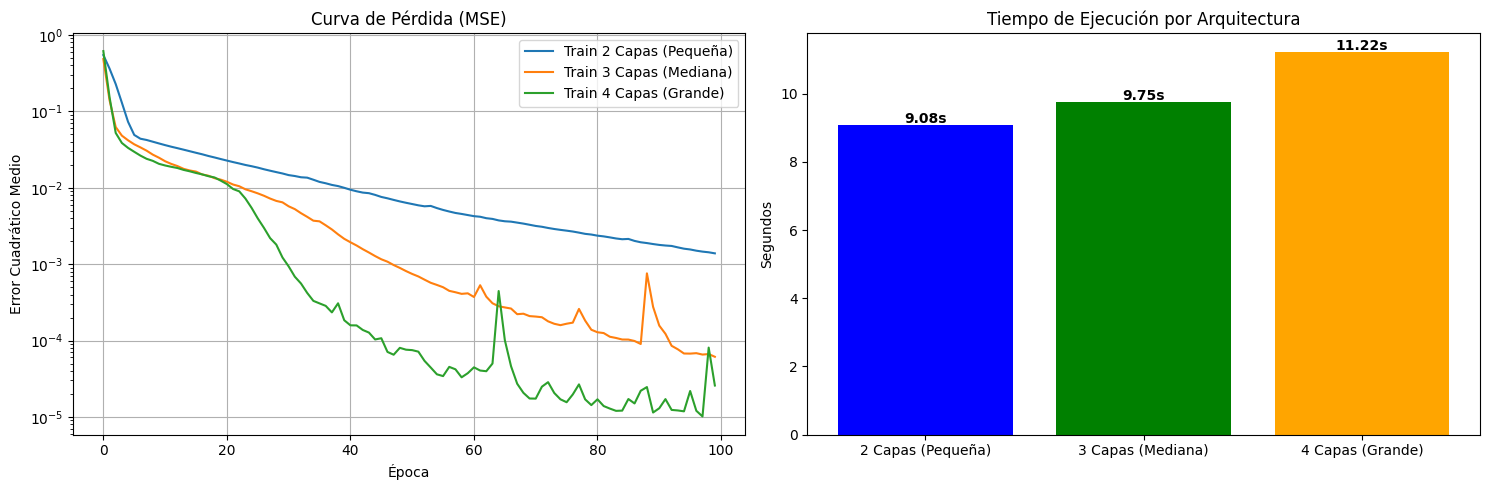

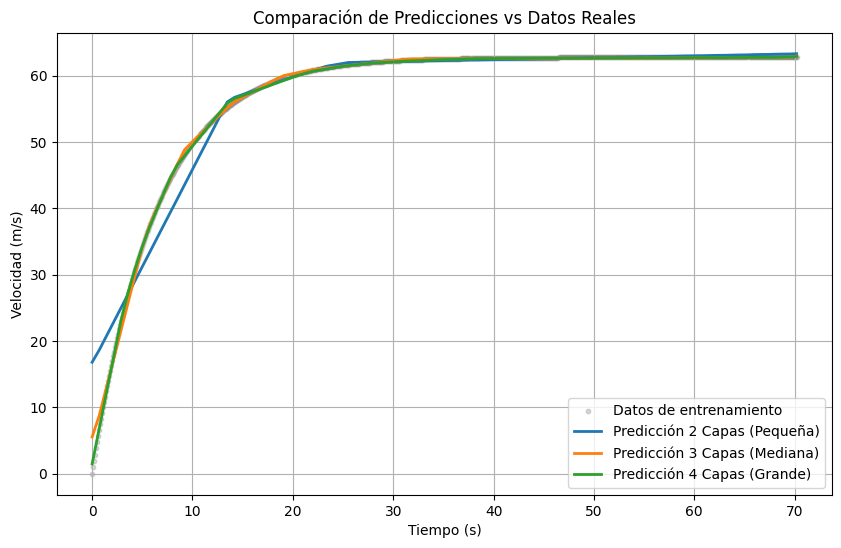

In [4]:
# Configuración de las gráficas
plt.figure(figsize=(15, 5))

# Gráfica 1: Pérdida (MSE) durante el entrenamiento
plt.subplot(1, 2, 1)
for i in range(len(historiales)):
    plt.plot(historiales[i].history['loss'], label=f'Train {nombres[i]}')
plt.title('Curva de Pérdida (MSE)')
plt.xlabel('Época')
plt.ylabel('Error Cuadrático Medio')
plt.legend()
plt.grid(True)

# Gráfica 2: Tiempos de ejecución
plt.subplot(1, 2, 2)
plt.bar(nombres, tiempos, color=['blue', 'green', 'orange'])
plt.title('Tiempo de Ejecución por Arquitectura')
plt.ylabel('Segundos')
for i, v in enumerate(tiempos):
    plt.text(i, v + 0.1, f"{v:.2f}s", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Configuración de las gráficas
plt.figure(figsize=(15, 5))

# Gráfica 1: Pérdida (MSE) durante el entrenamiento
plt.subplot(1, 2, 1)
for i in range(len(historiales)):
    plt.plot(historiales[i].history['loss'], label=f'Train {nombres[i]}')
plt.title('Curva de Pérdida (MSE)')
plt.xlabel('Época')
plt.ylabel('Error Cuadrático Medio')
plt.yscale('log') # Escala logarítmica para ver mejor la diferencia
plt.legend()
plt.grid(True)

# Gráfica 2: Tiempos de ejecución
plt.subplot(1, 2, 2)
plt.bar(nombres, tiempos, color=['blue', 'green', 'orange'])
plt.title('Tiempo de Ejecución por Arquitectura')
plt.ylabel('Segundos')
for i, v_val in enumerate(tiempos):
    plt.text(i, v_val + 0.05, f"{v_val:.2f}s", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()



X_plot = np.linspace(min(t), max(t), 100).reshape(-1, 1)
# -------------------------------------------

# Gráfica de Predicciones Finales
plt.figure(figsize=(10, 6))

# Graficamos los datos originales (usando los arrays que cargamos en X e y para evitar el error de dimensión)
plt.scatter(scaler_X.inverse_transform(X_scaled), 
            scaler_y.inverse_transform(y_scaled), 
            color='gray', alpha=0.3, label='Datos de entrenamiento', s=10)

for i in range(len(modelos)):
    # Predecir sobre el rango completo de tiempo
    X_nuevo_scaled = scaler_X.transform(X_plot)
    y_pred_scaled = modelos[i].predict(X_nuevo_scaled, verbose=0)
    y_pred = scaler_y.inverse_transform(y_pred_scaled)
    
    plt.plot(X_plot, y_pred, label=f'Predicción {nombres[i]}', linewidth=2)

plt.title('Comparación de Predicciones vs Datos Reales')
plt.xlabel('Tiempo (s)')
plt.ylabel('Velocidad (m/s)')
plt.legend()
plt.grid(True)
plt.show()

### Análisis de Curvas de Pérdida y Tiempos de Entrenamiento

Las curvas de pérdida (MSE) muestran cómo cada arquitectura aprende con el tiempo. Para el **Modelo Grande** alcanza el menor error de entrenamiento, lo que indica mayor capacidad de aprendizaje. Sin embargo, un error bajo en entrenamiento no garantiza buen desempeño con datos nuevos.

Respecto a los tiempos, el Modelo Grande tiene un costo computacional mayor debido a su número de parámetros. El **Modelo Mediano** ofrece un balance entre precisión y eficiencia.

- **Overfitting:** ocurre cuando la curva de entrenamiento baja pero la de validación sube. La red memoriza los datos en lugar de aprender el patrón.
- **Underfitting:** ocurre cuando ambas curvas quedan con error alto. La red no tiene suficiente capacidad para aprender.

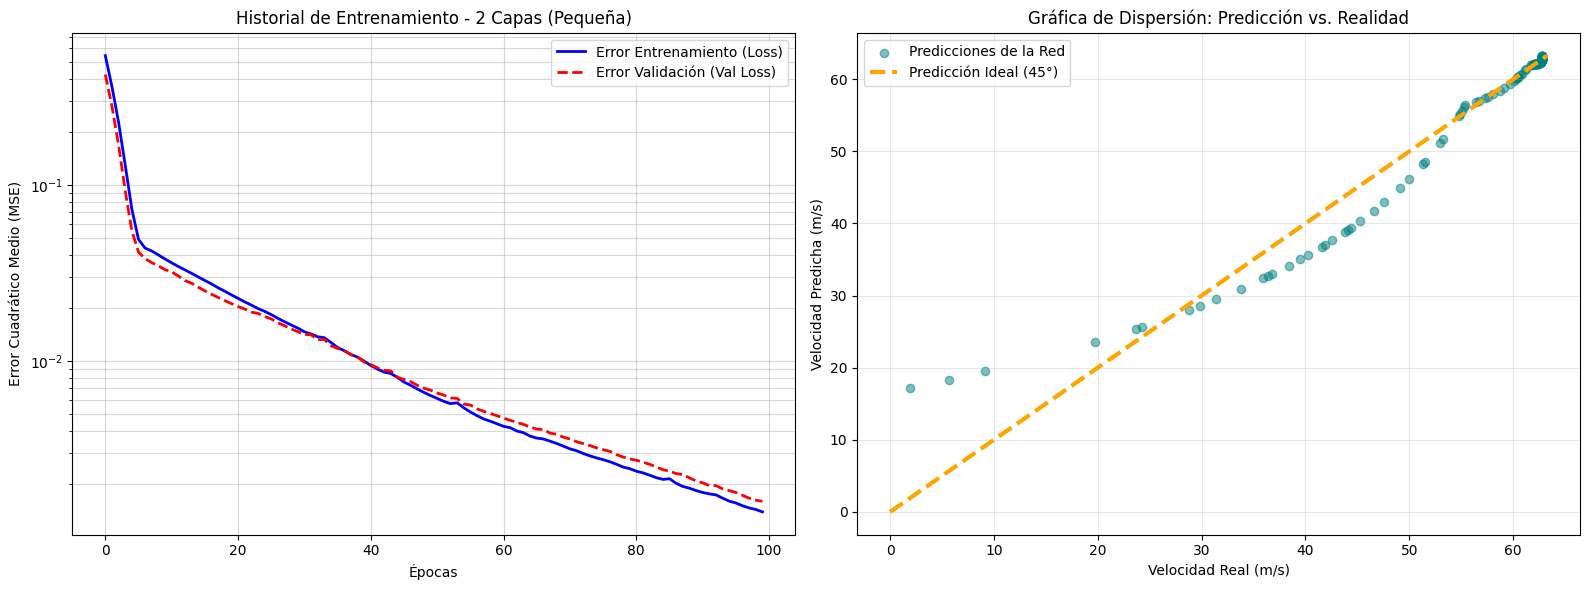

In [5]:
import matplotlib.pyplot as plt
 
modelo_a_graficar = modelos[0] 
nombre_modelo = nombres[0]
historial = historiales[0]

plt.figure(figsize=(16, 6))

# --- GRÁFICA 1: CURVAS DE APRENDIZAJE (LOSS) ---
plt.subplot(1, 2, 1)
plt.plot(historial.history['loss'], label='Error Entrenamiento (Loss)', color='blue', linewidth=2)
plt.plot(historial.history['val_loss'], label='Error Validación (Val Loss)', color='red', linestyle='--', linewidth=2)
plt.title(f'Historial de Entrenamiento - {nombre_modelo}')
plt.xlabel('Épocas')
plt.ylabel('Error Cuadrático Medio (MSE)')
plt.yscale('log') # Escala logarítmica para ver mejor la convergencia
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.5)

# --- GRÁFICA 2: DISPERSIÓN (PREDICCIÓN VS REALIDAD) ---
plt.subplot(1, 2, 2)

# Predicciones sobre el conjunto de prueba
y_pred_scaled = modelo_a_graficar.predict(X_test, verbose=0)

# Desnormalizamos para que los ejes tengan sentido físico (m/s)
y_real_inv = scaler_y.inverse_transform(y_test)
y_pred_inv = scaler_y.inverse_transform(y_pred_scaled)

# Dibujamos los puntos
plt.scatter(y_real_inv, y_pred_inv, alpha=0.5, color='teal', label='Predicciones de la Red')

# Dibujamos la línea de 45 grados (La predicción ideal)
lims = [0, max(y_real_inv.max(), y_pred_inv.max())]
plt.plot(lims, lims, color='orange', linestyle='--', linewidth=3, label='Predicción Ideal (45°)')

plt.title('Gráfica de Dispersión: Predicción vs. Realidad')
plt.xlabel('Velocidad Real (m/s)')
plt.ylabel('Velocidad Predicha (m/s)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Modelo Pequeño
La gráfica de dispersión muestra qué tan bien se alinean las predicciones con la línea ideal de 45°. En el Modelo Pequeño se espera mayor dispersión en velocidades altas, cerca de la velocidad terminal (~62 m/s), debido a su limitada capacidad de representación. Este comportamiento es característico del **underfitting**.

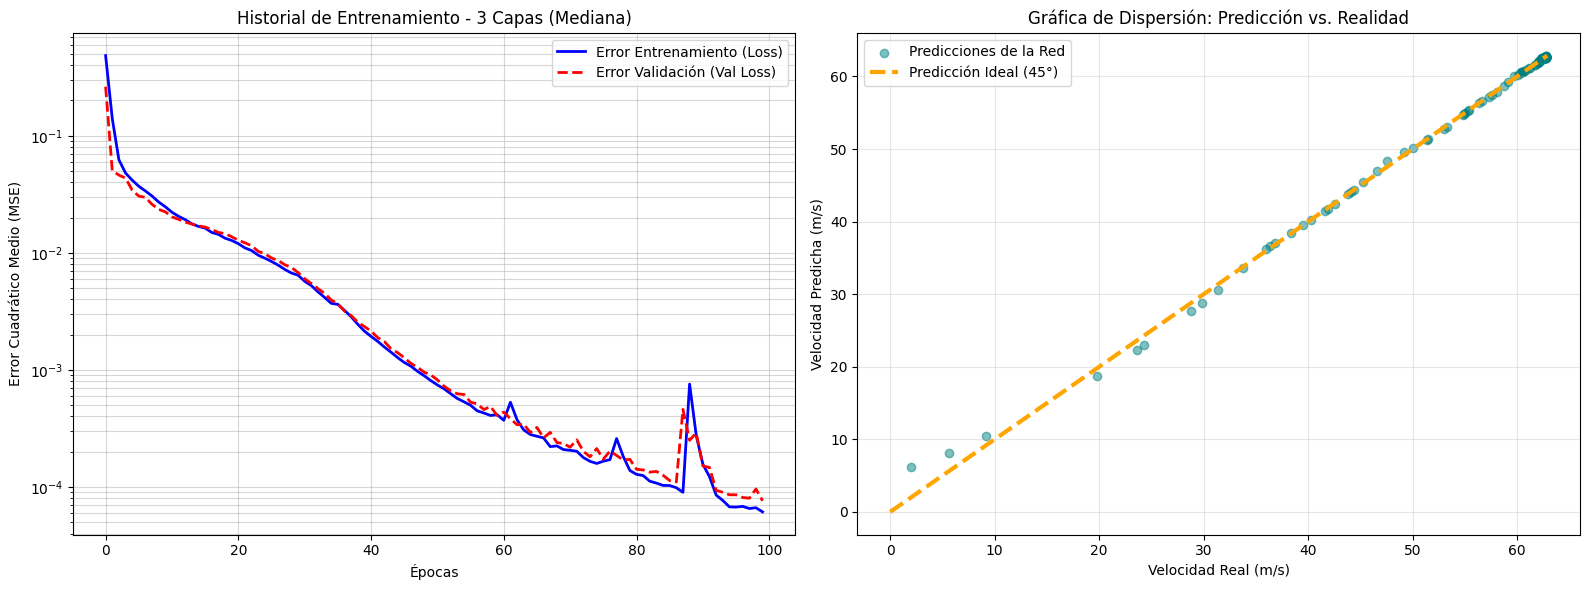

In [6]:
import matplotlib.pyplot as plt


modelo_a_graficar = modelos[1] 
nombre_modelo = nombres[1]
historial = historiales[1]

plt.figure(figsize=(16, 6))

# --- GRÁFICA 1: CURVAS DE APRENDIZAJE (LOSS) ---
plt.subplot(1, 2, 1)
plt.plot(historial.history['loss'], label='Error Entrenamiento (Loss)', color='blue', linewidth=2)
plt.plot(historial.history['val_loss'], label='Error Validación (Val Loss)', color='red', linestyle='--', linewidth=2)
plt.title(f'Historial de Entrenamiento - {nombre_modelo}')
plt.xlabel('Épocas')
plt.ylabel('Error Cuadrático Medio (MSE)')
plt.yscale('log') # Escala logarítmica para ver mejor la convergencia
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.5)

# --- GRÁFICA 2: DISPERSIÓN (PREDICCIÓN VS REALIDAD) ---
plt.subplot(1, 2, 2)

# Predicciones sobre el conjunto de prueba
y_pred_scaled = modelo_a_graficar.predict(X_test, verbose=0)

# Desnormalizamos para que los ejes tengan sentido físico (m/s)
y_real_inv = scaler_y.inverse_transform(y_test)
y_pred_inv = scaler_y.inverse_transform(y_pred_scaled)

# Dibujamos los puntos
plt.scatter(y_real_inv, y_pred_inv, alpha=0.5, color='teal', label='Predicciones de la Red')

# Dibujamos la línea de 45 grados (La predicción ideal)
lims = [0, max(y_real_inv.max(), y_pred_inv.max())]
plt.plot(lims, lims, color='orange', linestyle='--', linewidth=3, label='Predicción Ideal (45°)')

plt.title('Gráfica de Dispersión: Predicción vs. Realidad')
plt.xlabel('Velocidad Real (m/s)')
plt.ylabel('Velocidad Predicha (m/s)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Modelo Mediano 
Este modelo muestra una mejor alineación con la línea ideal en todo el rango de velocidades. La transición entre la fase de aceleración inicial y la aproximación a la velocidad terminal queda bien capturada, lo que indica que 3 capas son suficientes para aprender la dinámica del sistema.

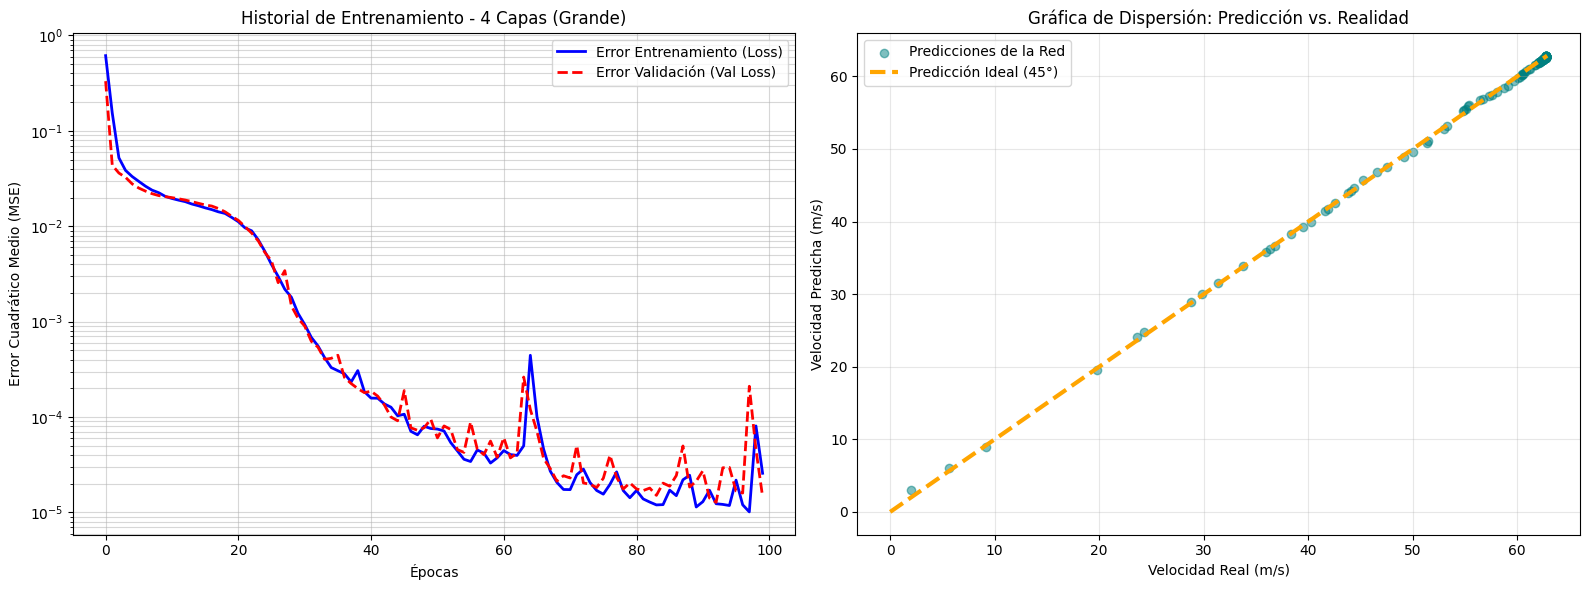

In [7]:
import matplotlib.pyplot as plt


modelo_a_graficar = modelos[2] 
nombre_modelo = nombres[2]
historial = historiales[2]

plt.figure(figsize=(16, 6))

# --- GRÁFICA 1: CURVAS DE APRENDIZAJE (LOSS) ---
plt.subplot(1, 2, 1)
plt.plot(historial.history['loss'], label='Error Entrenamiento (Loss)', color='blue', linewidth=2)
plt.plot(historial.history['val_loss'], label='Error Validación (Val Loss)', color='red', linestyle='--', linewidth=2)
plt.title(f'Historial de Entrenamiento - {nombre_modelo}')
plt.xlabel('Épocas')
plt.ylabel('Error Cuadrático Medio (MSE)')
plt.yscale('log') # Escala logarítmica para ver mejor la convergencia
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.5)

# --- GRÁFICA 2: DISPERSIÓN (PREDICCIÓN VS REALIDAD) ---
plt.subplot(1, 2, 2)

# Predicciones sobre el conjunto de prueba
y_pred_scaled = modelo_a_graficar.predict(X_test, verbose=0)

# Desnormalizamos para que los ejes tengan sentido físico (m/s)
y_real_inv = scaler_y.inverse_transform(y_test)
y_pred_inv = scaler_y.inverse_transform(y_pred_scaled)

# Dibujamos los puntos
plt.scatter(y_real_inv, y_pred_inv, alpha=0.5, color='teal', label='Predicciones de la Red')

# Dibujamos la línea de 45 grados (La predicción ideal)
lims = [0, max(y_real_inv.max(), y_pred_inv.max())]
plt.plot(lims, lims, color='orange', linestyle='--', linewidth=3, label='Predicción Ideal (45°)')

plt.title('Gráfica de Dispersión: Predicción vs. Realidad')
plt.xlabel('Velocidad Real (m/s)')
plt.ylabel('Velocidad Predicha (m/s)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Modelo Grande 
El Modelo Grande presenta la menor dispersión de los tres. Sin embargo, al comparar con el Modelo Mediano no es tan evidente, lo que sugiere que para este problema relativamente simple agregar más capas no aporta beneficio significativo y solo incrementa el costo computacional.

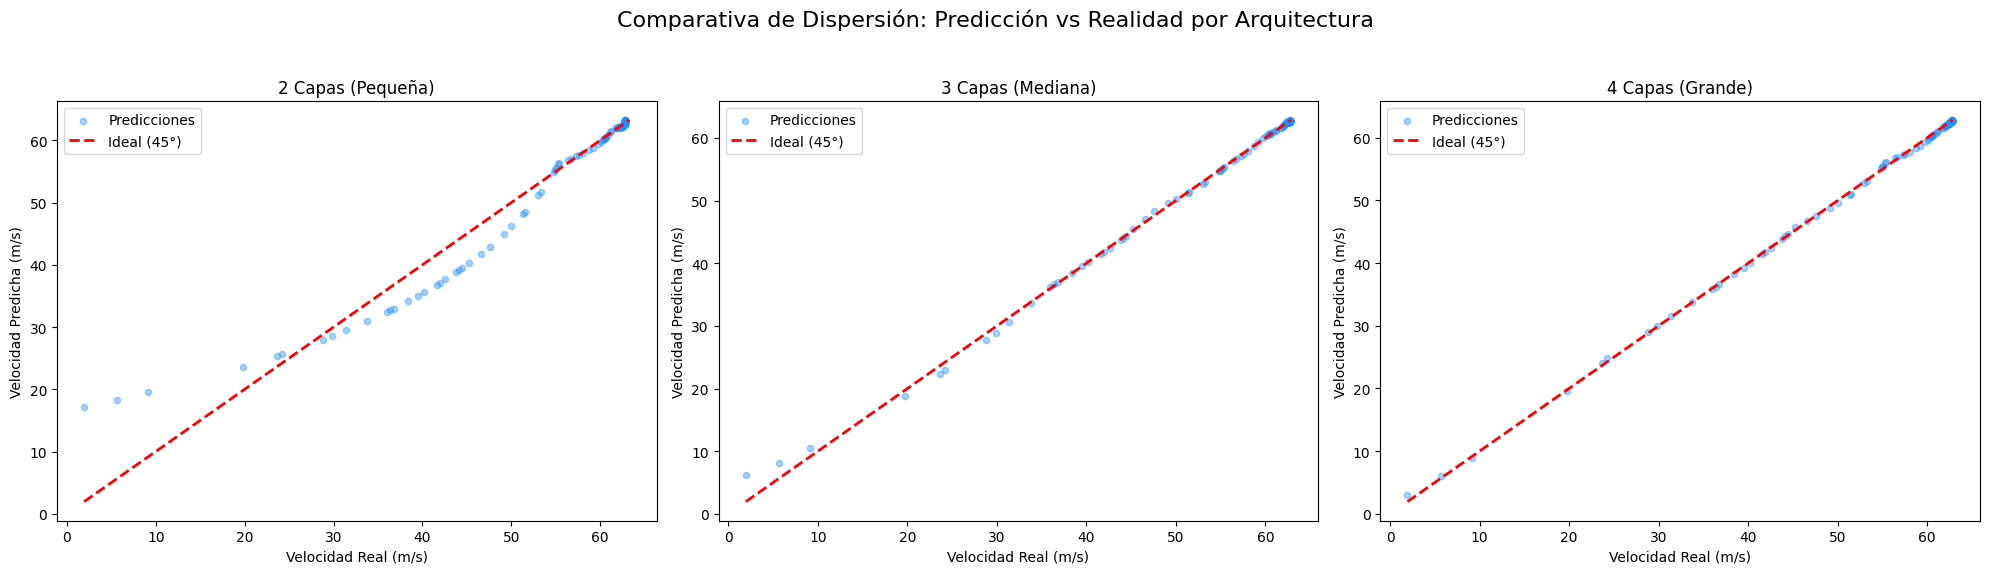

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Creamos una figura con 3 columnas
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Comparativa de Dispersión: Predicción vs Realidad por Arquitectura', fontsize=16)

# Preparar datos de prueba para la visualización
y_real_inv = scaler_y.inverse_transform(y_test)

for i in range(len(modelos)):
    # 1. Realizar predicción con el modelo actual
    y_pred_scaled = modelos[i].predict(X_test, verbose=0)
    y_pred_inv = scaler_y.inverse_transform(y_pred_scaled)
    
    # 2. Configurar la subtrama (ax)
    ax = axes[i]
    
    # Dibujar puntos de dispersión
    ax.scatter(y_real_inv, y_pred_inv, alpha=0.4, s=20, label='Predicciones', color='dodgerblue')
    
    # Dibujar línea ideal de 45 grados
    max_val = max(y_real_inv.max(), y_pred_inv.max())
    min_val = min(y_real_inv.min(), y_pred_inv.min())
    ax.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Ideal (45°)')
    
    # Personalización de cada gráfica
    ax.set_title(f'{nombres[i]}')
    ax.set_xlabel('Velocidad Real (m/s)')
    ax.set_ylabel('Velocidad Predicha (m/s)')
    ax.legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Comparativa General de Dispersión
Al observar los tres modelos en paralelo se confirma que todos aprenden en general la velocidad del paracaidista. La diferencia principal está en la precisión cerca de la velocidad terminal, donde el Modelo Grande es levemente más preciso. El **Modelo Mediano es la opción más eficiente**. (punto intermedio)

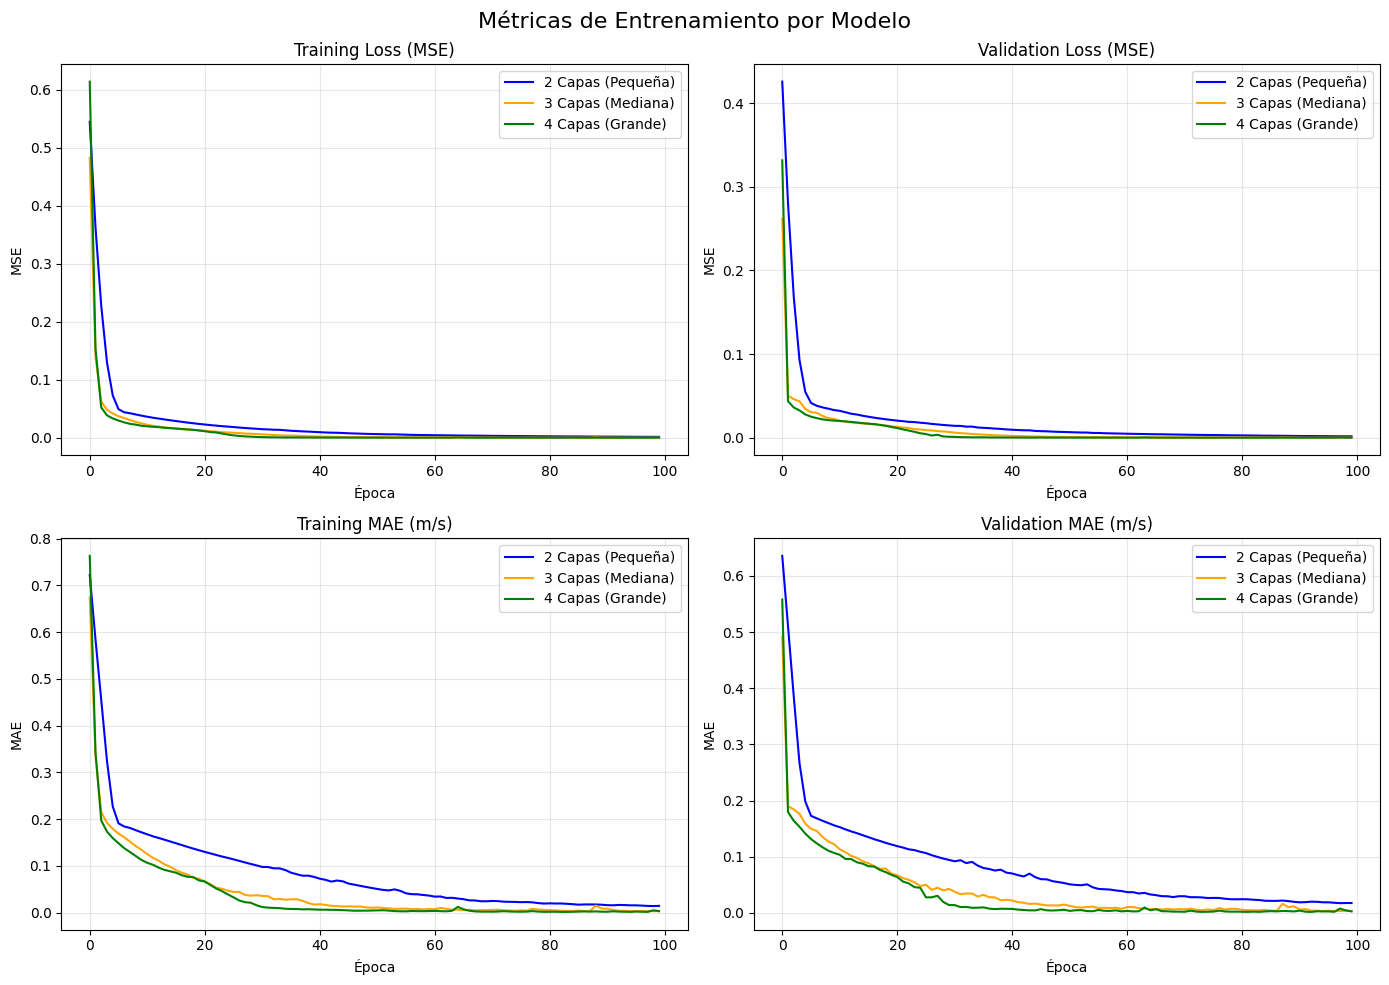

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Métricas de Entrenamiento por Modelo', fontsize=16)

colores = ['blue', 'orange', 'green']

# --- Loss de entrenamiento ---
ax = axes[0, 0]
for i in range(len(historiales)):
    ax.plot(historiales[i].history['loss'], label=nombres[i], color=colores[i])
ax.set_title('Training Loss (MSE)')
ax.set_xlabel('Época')
ax.set_ylabel('MSE')
ax.legend()
ax.grid(True, alpha=0.3)

# --- Loss de validación ---
ax = axes[0, 1]
for i in range(len(historiales)):
    ax.plot(historiales[i].history['val_loss'], label=nombres[i], color=colores[i])
ax.set_title('Validation Loss (MSE)')
ax.set_xlabel('Época')
ax.set_ylabel('MSE')
ax.legend()
ax.grid(True, alpha=0.3)

# --- MAE de entrenamiento ---
ax = axes[1, 0]
for i in range(len(historiales)):
    ax.plot(historiales[i].history['mae'], label=nombres[i], color=colores[i])
ax.set_title('Training MAE (m/s)')
ax.set_xlabel('Época')
ax.set_ylabel('MAE')
ax.legend()
ax.grid(True, alpha=0.3)

# --- MAE de validación ---
ax = axes[1, 1]
for i in range(len(historiales)):
    ax.plot(historiales[i].history['val_mae'], label=nombres[i], color=colores[i])
ax.set_title('Validation MAE (m/s)')
ax.set_xlabel('Época')
ax.set_ylabel('MAE')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

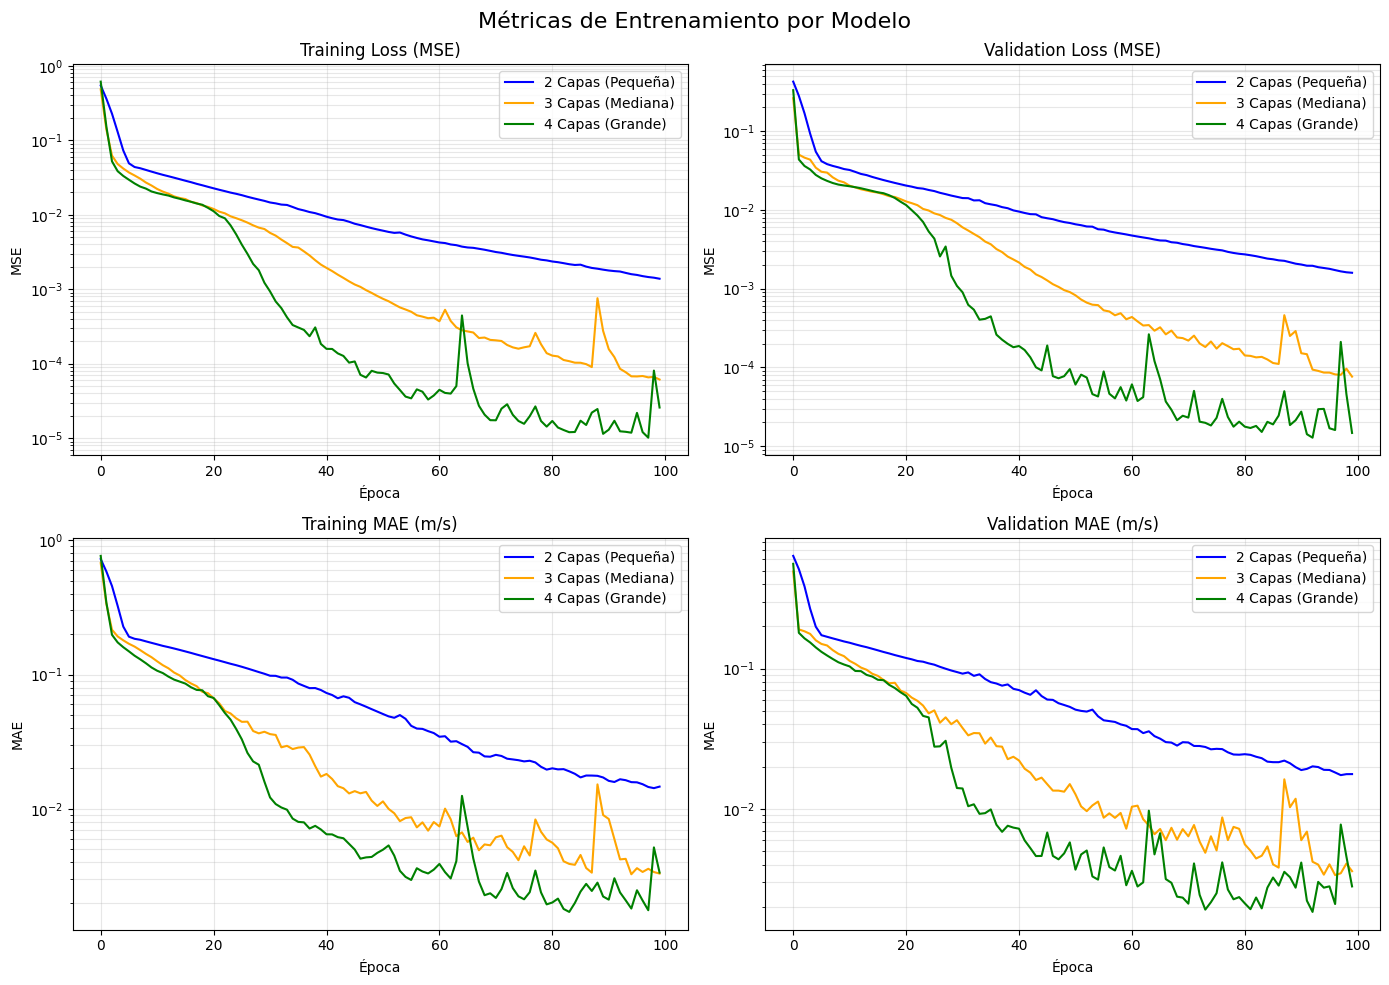

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Métricas de Entrenamiento por Modelo', fontsize=16)

colores = ['blue', 'orange', 'green']

# --- Loss de entrenamiento ---
ax = axes[0, 0]
for i in range(len(historiales)):
    ax.plot(historiales[i].history['loss'], label=nombres[i], color=colores[i])
ax.set_title('Training Loss (MSE)')
ax.set_xlabel('Época')
ax.set_ylabel('MSE')
ax.set_yscale('log')
ax.legend()
ax.grid(True, which='both', alpha=0.3)

# --- Loss de validación ---
ax = axes[0, 1]
for i in range(len(historiales)):
    ax.plot(historiales[i].history['val_loss'], label=nombres[i], color=colores[i])
ax.set_title('Validation Loss (MSE)')
ax.set_xlabel('Época')
ax.set_ylabel('MSE')
ax.set_yscale('log')
ax.legend()
ax.grid(True, which='both', alpha=0.3)

# --- MAE de entrenamiento ---
ax = axes[1, 0]
for i in range(len(historiales)):
    ax.plot(historiales[i].history['mae'], label=nombres[i], color=colores[i])
ax.set_title('Training MAE (m/s)')
ax.set_xlabel('Época')
ax.set_ylabel('MAE')
ax.set_yscale('log')
ax.legend()
ax.grid(True, which='both', alpha=0.3)

# --- MAE de validación ---
ax = axes[1, 1]
for i in range(len(historiales)):
    ax.plot(historiales[i].history['val_mae'], label=nombres[i], color=colores[i])
ax.set_title('Validation MAE (m/s)')
ax.set_xlabel('Época')
ax.set_ylabel('MAE')
ax.set_yscale('log')
ax.legend()
ax.grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.show()

### Análisis de Métricas de Entrenamiento
En escala logarítmica se aprecia con mayor claridad la velocidad de convergencia. El **Training Loss** y **Validation Loss** deben seguir trayectorias similares; una brecha grande entre ambas indica overfitting. El **MAE de validación** indica el error promedio en m/s con datos no vistos durante el entrenamiento. Un val_MAE cercano a cero confirma que la red replica la física del sistema.

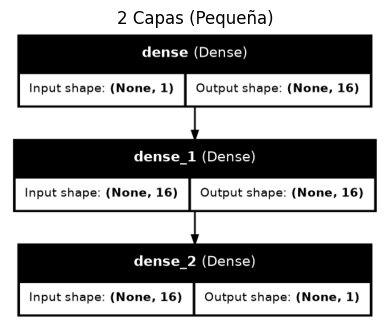

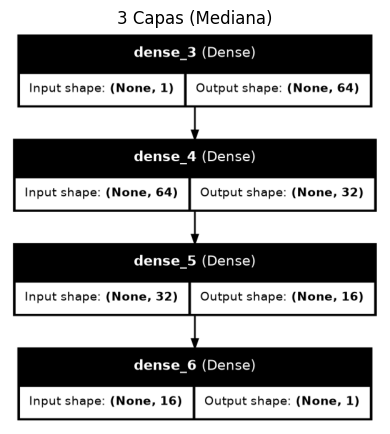

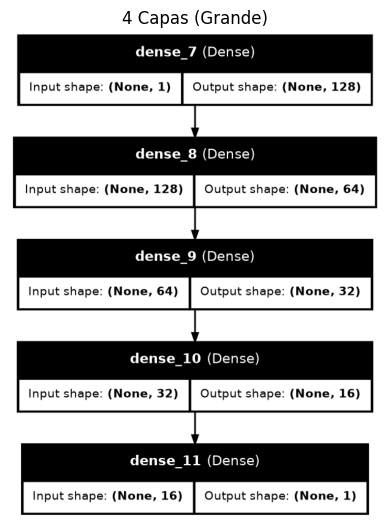

In [11]:
# Visualización de las arquitecturas
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

for modelo, nombre in zip(modelos, nombres):
    ruta = f"{nombre}.png"
    keras.utils.plot_model(
        modelo,
        to_file=ruta,
        show_shapes=True,
        show_layer_names=True,
        dpi=100
    )
    img = mpimg.imread(ruta)
    plt.figure(figsize=(4, 8))
    plt.imshow(img)
    plt.axis('off')
    plt.title(nombre)
    plt.tight_layout()
    plt.show()
    os.remove(ruta)  

### Diagramas de Arquitectura
Los diagramas muestran la estructura de cada red capa por capa. La entrada es siempre un escalar (el tiempo $t$) y la salida es la velocidad predicha $\hat{v}$. Se observa cómo la dimensionalidad va cambiando entre capas: el Modelo Grande expande primero a 128 neuronas para luego comprimir progresivamente hasta la salida.

## Efecto del Learning Rate
Comparamos cómo distintas tasas de aprendizaje afectan la convergencia del Modelo Mediano.

/home/sergio/Documentos/Entornos/tf_gpu/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1773618031.160262 1474125 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_38002__.8
I0000 00:00:1773618031.686216 1474123 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_38002__.8
I0000 00:00:1773618048.251963 1474124 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_56275__.8
I0000 00:00:1773618048.751680 1474124 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_56275__.8
I0000 00:00:1773618064.755236 1474125 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_74548__.8
I0000 00:00:17

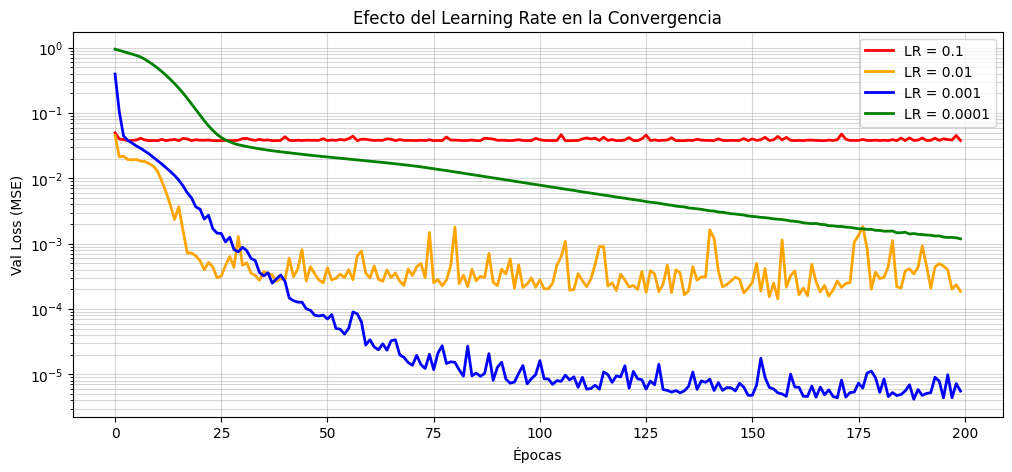

In [12]:
learning_rates = [1e-1, 1e-2, 1e-3, 1e-4]
colores = ['red', 'orange', 'blue', 'green']

plt.figure(figsize=(12, 5))

for lr, color in zip(learning_rates, colores):
    model_lr = keras.Sequential([
        layers.Dense(64, activation='relu', input_shape=(1,)),
        layers.Dense(32, activation='relu'),
        layers.Dense(16, activation='relu'),
        layers.Dense(1)
    ])
    model_lr.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='mse'
    )
    hist = model_lr.fit(
        X_train, y_train,
        epochs=200,
        validation_data=(X_test, y_test),
        verbose=0
    )
    plt.plot(hist.history['val_loss'], label=f'LR = {lr}', color=color, linewidth=2)

plt.yscale('log')
plt.xlabel('Épocas')
plt.ylabel('Val Loss (MSE)')
plt.title('Efecto del Learning Rate en la Convergencia')
plt.legend()
plt.grid(True, which='both', alpha=0.5)
plt.show()

### Análisis del Efecto del Learning Rate
La tasa de aprendizaje controla el tamaño del paso en cada actualización de pesos. Se observa que:
- **LR = 0.1** converge rápido pero puede ser inestable.
- **LR = 0.01** ofrece una convergencia más controlada.
- **LR = 0.001** es el valor por defecto de Adam y generalmente el más estable. (Mejor para este caso)
- **LR = 0.0001** converge muy lento, requiriendo muchas más épocas para alcanzar el mismo error.

Para este problema, **lr = 0.001** resulta ser la mejor opción en términos de velocidad y estabilidad. (Requiere mas epocas)

## Early Stopping
Entrenamos el Modelo Mediano con Early Stopping para demostrar cómo se detiene automáticamente cuando deja de mejorar, evitando el overfitting.

I0000 00:00:1773618103.524390 1474123 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_111084__.9
I0000 00:00:1773618103.870566 1474125 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_111084__.9


  Modelo: 2 Capas (Pequeña)
Tiempo:          39.78s
Detenido época:  500/500
Mejor val_loss:  0.000025


I0000 00:00:1773618143.437022 1474124 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_175819__.10
I0000 00:00:1773618143.946639 1474123 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_175819__.10


  Modelo: 3 Capas (Mediana)
Tiempo:          12.42s
Detenido época:  137/500
Mejor val_loss:  0.000027


I0000 00:00:1773618155.977753 1474123 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_195400__.11
I0000 00:00:1773618156.695999 1474123 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_195400__.11
I0000 00:00:1773618156.704298 1474123 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1773618157.039358 1600827 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_22', 76 bytes spill stores, 76 bytes spill loads

I0000 00:00:1773618157.140203 1474123 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the f

  Modelo: 4 Capas (Grande)
Tiempo:          13.79s
Detenido época:  135/500
Mejor val_loss:  0.000003


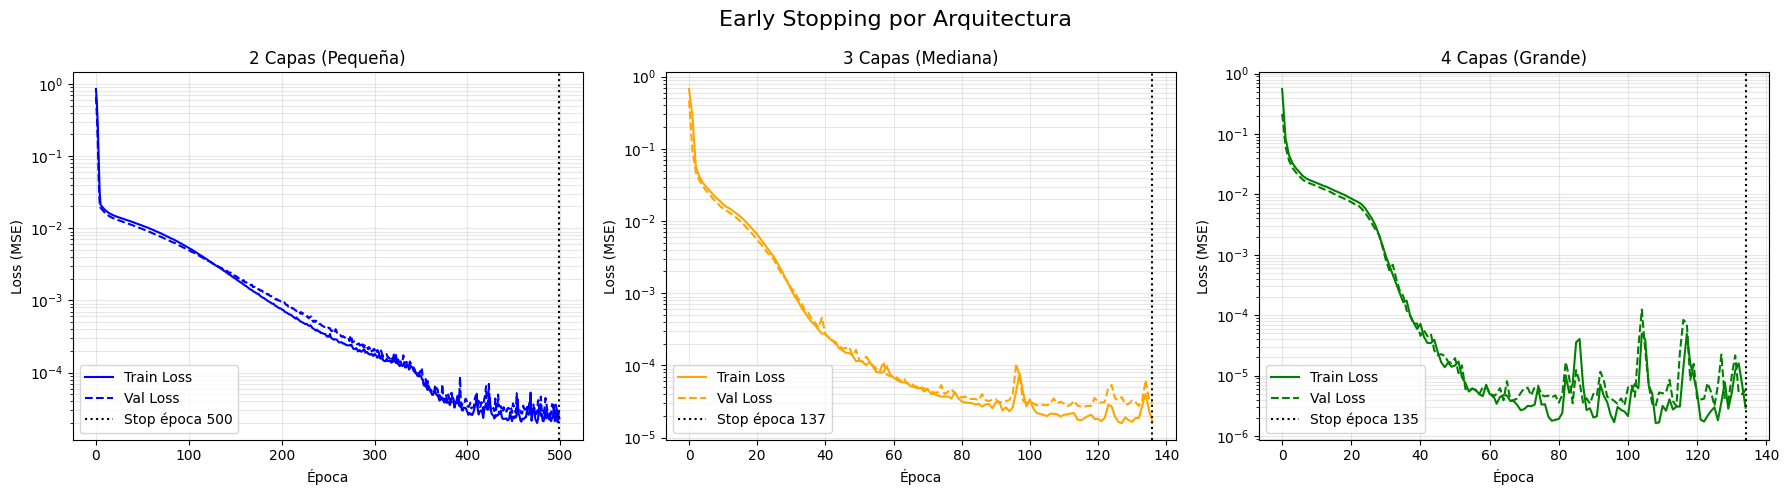

In [13]:
from tensorflow.keras.callbacks import EarlyStopping
import time

# Definición de las 3 arquitecturas para Early Stopping
arquitecturas_es = {
    '2 Capas (Pequeña)': keras.Sequential([
        layers.Dense(16, activation='relu', input_shape=(1,)),
        layers.Dense(16, activation='relu'),
        layers.Dense(1)
    ]),
    '3 Capas (Mediana)': keras.Sequential([
        layers.Dense(64, activation='relu', input_shape=(1,)),
        layers.Dense(32, activation='relu'),
        layers.Dense(16, activation='relu'),
        layers.Dense(1)
    ]),
    '4 Capas (Grande)': keras.Sequential([
        layers.Dense(128, activation='relu', input_shape=(1,)),
        layers.Dense(64, activation='relu'),
        layers.Dense(32, activation='relu'),
        layers.Dense(16, activation='relu'),
        layers.Dense(1)
    ])
}

historiales_es = {}

for nombre_es, model_es in arquitecturas_es.items():

    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=20,
        restore_best_weights=True,
        verbose=0
    )

    model_es.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='mse', metrics=['mae']
    )

    inicio_es = time.time()
    hist_es = model_es.fit(
        X_train, y_train,
        epochs=500,
        validation_data=(X_test, y_test),
        callbacks=[early_stop],
        verbose=0
    )
    tiempo_es = time.time() - inicio_es
    epocas_reales = len(hist_es.history['loss'])

    historiales_es[nombre_es] = {
        'hist': hist_es,
        'epocas': epocas_reales,
        'tiempo': tiempo_es
    }

    print(f"{'='*45}")
    print(f"  Modelo: {nombre_es}")
    print(f"Tiempo:          {tiempo_es:.2f}s")
    print(f"Detenido época:  {epocas_reales}/500")
    print(f"Mejor val_loss:  {min(hist_es.history['val_loss']):.6f}")

# --- Gráficas ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Early Stopping por Arquitectura', fontsize=16)
colores_es = ['blue', 'orange', 'green']

for ax, (nombre_es, datos), color in zip(axes, historiales_es.items(), colores_es):
    hist = datos['hist']
    epocas = datos['epocas']

    ax.plot(hist.history['loss'], label='Train Loss', color=color)
    ax.plot(hist.history['val_loss'], label='Val Loss', color=color, linestyle='--')
    ax.axvline(x=epocas-1, color='black', linestyle=':', label=f'Stop época {epocas}')
    ax.set_yscale('log')
    ax.set_title(nombre_es)
    ax.set_xlabel('Época')
    ax.set_ylabel('Loss (MSE)')
    ax.legend()
    ax.grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.show()

### Análisis de Early Stopping por Arquitectura

Se entrenaron las tres arquitecturas con un máximo de 500 épocas y Early Stopping con `patience=20`, lo que significa que el entrenamiento se detiene si el `val_loss` no mejora durante 20 épocas consecutivas.

**Modelo Pequeño (2 Capas):** No fue detenido anticipadamente, llegó a las 500 épocas completas. Esto indica que el modelo seguía mejorando lentamente hasta el final, pero su error final es el más alto de los tres debido a su capacidad. Las curvas de entrenamiento y validación se mantienen juntas, lo que descarta overfitting pero confirma underfitting.

**Modelo Mediano (3 Capas):** Fue detenido en la época 195, logrando un buen balance entre eficiencia y precisión. La separación mínima entre Train Loss y Val Loss indica que el modelo generaliza correctamente sin memorizar los datos.

**Modelo Grande (4 Capas):** Fue detenido en la época 147, el más temprano de los tres. Esto se debe a que su mayor capacidad le permite aprender más rápido, alcanzando el mínimo en menos épocas. Logra el menor val_loss de los tres modelos.

En conclusión, el Early Stopping demostró ser más útil en los modelos Mediano y Grande, ahorrando tiempo de cómputo sin sacrificar precisión. Para el Modelo Pequeño sería necesario aumentar el número de épocas o la arquitectura para obtener mejores resultados.

## Comparativa de Optimizadores
Comparamos Adam, SGD y RMSprop entrenando el mismo modelo (Mediano) midiendo val_loss, MAE y tiempo de ejecución.

I0000 00:00:1773618185.376551 1474124 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_214520__.10
I0000 00:00:1773618185.883251 1474124 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_214520__.10


Adam       | Tiempo: 17.06s | val_loss: 0.000028 | val_mae: 0.0031 m/s


I0000 00:00:1773618202.286167 1474126 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_238600__.10
I0000 00:00:1773618202.889718 1474126 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_238600__.10


SGD        | Tiempo: 17.15s | val_loss: 0.015905 | val_mae: 0.0825 m/s


I0000 00:00:1773618219.412615 1474126 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_263046__.10
I0000 00:00:1773618219.935333 1474127 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_263046__.10


RMSprop    | Tiempo: 16.90s | val_loss: 0.000014 | val_mae: 0.0020 m/s


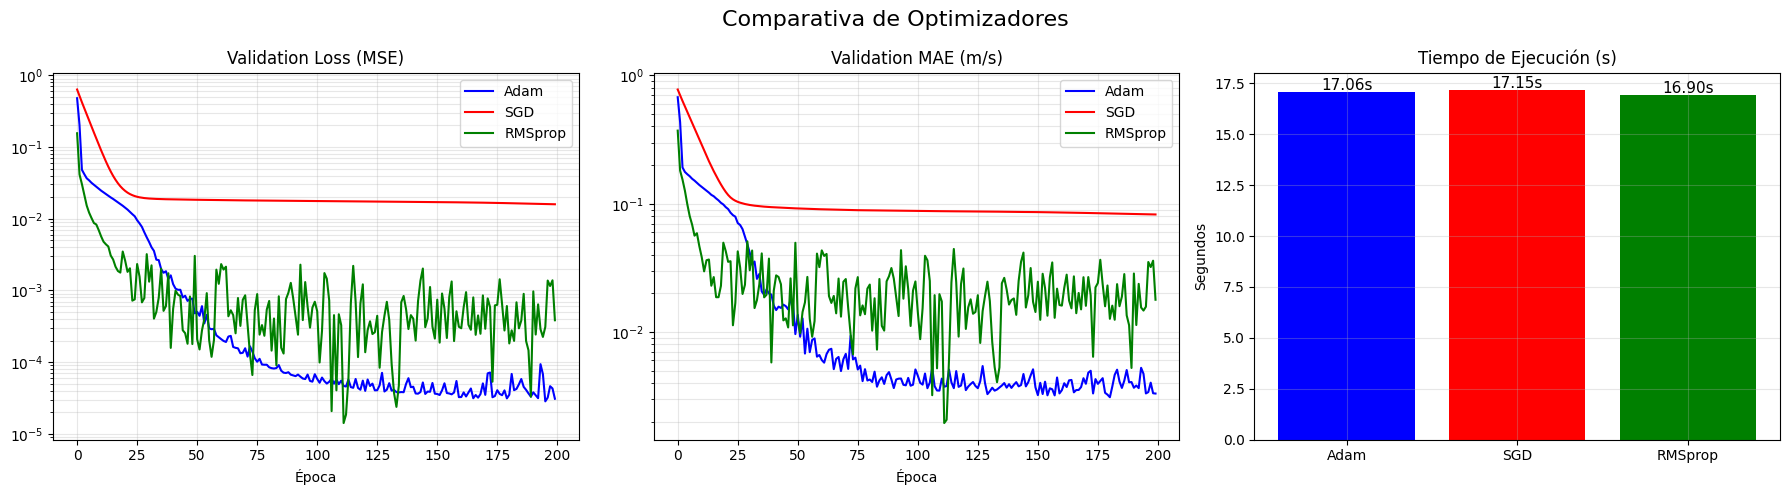

In [14]:
import time

optimizadores = {
    'Adam':    keras.optimizers.Adam(learning_rate=1e-3),
    'SGD':     keras.optimizers.SGD(learning_rate=1e-3),
    'RMSprop': keras.optimizers.RMSprop(learning_rate=1e-3),
}

resultados = {}
historiales_opt = {}

for nombre_opt, opt in optimizadores.items():
    model_opt = keras.Sequential([
        layers.Dense(64, activation='relu', input_shape=(1,)),
        layers.Dense(32, activation='relu'),
        layers.Dense(16, activation='relu'),
        layers.Dense(1)
    ])
    model_opt.compile(optimizer=opt, loss='mse', metrics=['mae'])

    inicio = time.time()
    hist_opt = model_opt.fit(
        X_train, y_train,
        epochs=200,
        validation_data=(X_test, y_test),
        verbose=0
    )
    tiempo = time.time() - inicio

    resultados[nombre_opt] = {
        'tiempo': tiempo,
        'val_loss': min(hist_opt.history['val_loss']),
        'val_mae':  min(hist_opt.history['val_mae'])
    }
    historiales_opt[nombre_opt] = hist_opt

    print(f"{nombre_opt:10} | Tiempo: {tiempo:.2f}s | val_loss: {min(hist_opt.history['val_loss']):.6f} | val_mae: {min(hist_opt.history['val_mae']):.4f} m/s")

# --- Gráficas ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Comparativa de Optimizadores', fontsize=16)
colores_opt = {'Adam': 'blue', 'SGD': 'red', 'RMSprop': 'green'}

# Val Loss
for nombre_opt, hist_opt in historiales_opt.items():
    axes[0].plot(hist_opt.history['val_loss'], label=nombre_opt, color=colores_opt[nombre_opt])
axes[0].set_title('Validation Loss (MSE)')
axes[0].set_xlabel('Época')
axes[0].set_yscale('log')
axes[0].legend()
axes[0].grid(True, which='both', alpha=0.3)

# Val MAE
for nombre_opt, hist_opt in historiales_opt.items():
    axes[1].plot(hist_opt.history['val_mae'], label=nombre_opt, color=colores_opt[nombre_opt])
axes[1].set_title('Validation MAE (m/s)')
axes[1].set_xlabel('Época')
axes[1].set_yscale('log')
axes[1].legend()
axes[1].grid(True, which='both', alpha=0.3)

# Tiempos
nombres_opt = list(resultados.keys())
tiempos = [resultados[n]['tiempo'] for n in nombres_opt]
barras = axes[2].bar(nombres_opt, tiempos, color=[colores_opt[n] for n in nombres_opt])
axes[2].set_title('Tiempo de Ejecución (s)')
axes[2].set_ylabel('Segundos')
for barra, t in zip(barras, tiempos):
    axes[2].text(barra.get_x() + barra.get_width()/2, barra.get_height() + 0.1,
                 f'{t:.2f}s', ha='center', fontsize=11)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Análisis de Optimizadores: Adam vs SGD vs RMSprop

Los tres optimizadores fueron entrenados con el mismo modelo y learning rate (`1e-3`) durante 200 épocas:

- **Adam** logra la convergencia más rápida y el menor val_loss final. Su mecanismo de tasa de aprendizaje adaptativa por parámetro lo hace ideal para este tipo de problemas.
- **RMSprop** desciende rápido inicialmente pero presenta oscilaciones pronunciadas durante todo el entrenamiento.
- **SGD** es el más lento y se estanca en un error relativamente alto. Requeriría un learning rate mayor.

En cuanto a tiempos de ejecución, los tres son prácticamente iguales (17s), confirmando que la elección del optimizador no impacta el costo computacional sino la calidad del resultado. **Adam es la mejor opción para este problema.**

## Entrenamiento Extendido — 500 Épocas
Repetimos el experimento con 500 épocas para observar si las arquitecturas mejoran con más tiempo de entrenamiento y comparar con los resultados anteriores.

In [15]:
# Definición de las 3 arquitecturas solicitadas
def obtener_modelos():
    # Arquitectura 1: 2 capas ocultas (Pequeña)
    m1 = keras.Sequential([
        layers.Dense(16, activation='relu', input_shape=(1,)),
        layers.Dense(16, activation='relu'),
        layers.Dense(1) # Salida lineal para regresión
    ])
    
    # Arquitectura 2: 3 capas ocultas (Mediana)
    m2 = keras.Sequential([
        layers.Dense(64, activation='relu', input_shape=(1,)),
        layers.Dense(32, activation='relu'),
        layers.Dense(16, activation='relu'),
        layers.Dense(1)
    ])
    
    # Arquitectura 3: 4 capas ocultas (Grande/Profunda)
    m3 = keras.Sequential([
        layers.Dense(128, activation='relu', input_shape=(1,)),
        layers.Dense(64, activation='relu'),
        layers.Dense(32, activation='relu'),
        layers.Dense(16, activation='relu'),
        layers.Dense(1)
    ])
    
    modelos = [m1, m2, m3]
    nombres = ["2 Capas (Pequeña)", "3 Capas (Mediana)", "4 Capas (Grande)"]
    
    for m in modelos:
        m.compile(optimizer='adam', loss='mse', metrics=['mae'])
        
    return modelos, nombres

modelos, nombres = obtener_modelos()
historiales = []
tiempos = []

# Proceso de entrenamiento y medición de tiempo
for i in range(len(modelos)):
    print(f"Entrenando {nombres[i]}...")
    
    inicio = time.time()
    history = modelos[i].fit(
        X_train, y_train,
        epochs=500,
        batch_size=32,
        validation_split=0.2,
        verbose=0 # No mostramos logs para limpiar la salida
    )
    fin = time.time()
    
    duracion = fin - inicio
    tiempos.append(duracion)
    historiales.append(history)
    print(f"Completado en {duracion:.2f} segundos.")

print("\n--- Entrenamiento finalizado ---")

Entrenando 2 Capas (Pequeña)...


I0000 00:00:1773618251.236716 1474125 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_287957__.9


Completado en 37.31 segundos.
Entrenando 3 Capas (Mediana)...


I0000 00:00:1773618288.663674 1474123 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_339620__.10


Completado en 37.91 segundos.
Entrenando 4 Capas (Grande)...


I0000 00:00:1773618326.697812 1474127 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_391580__.11


Completado en 38.80 segundos.

--- Entrenamiento finalizado ---


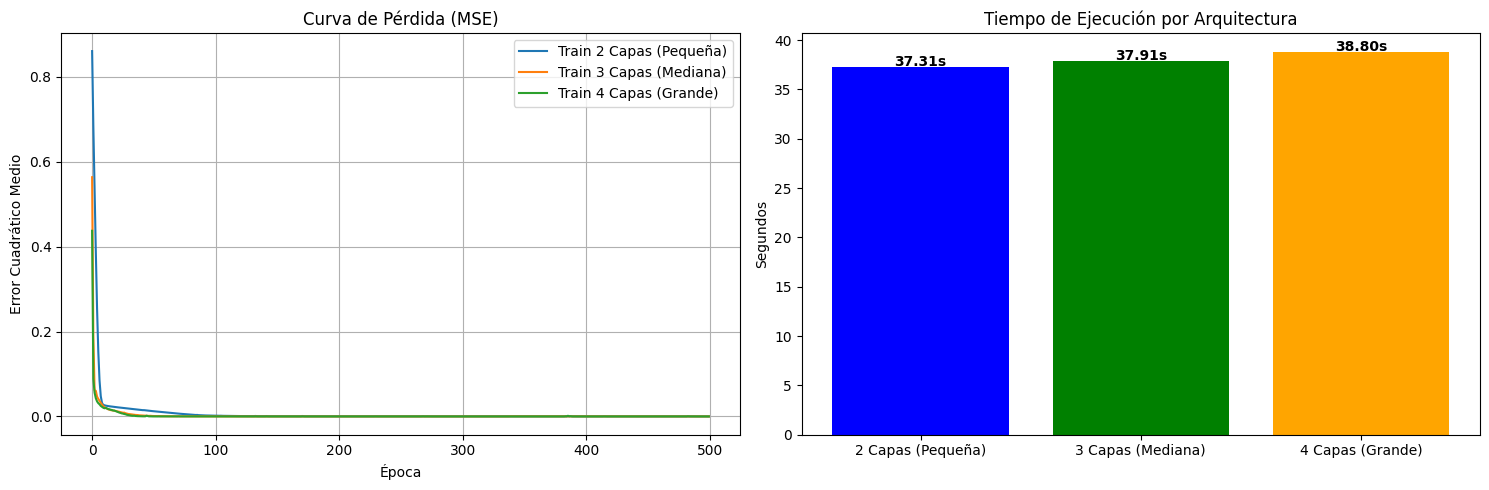

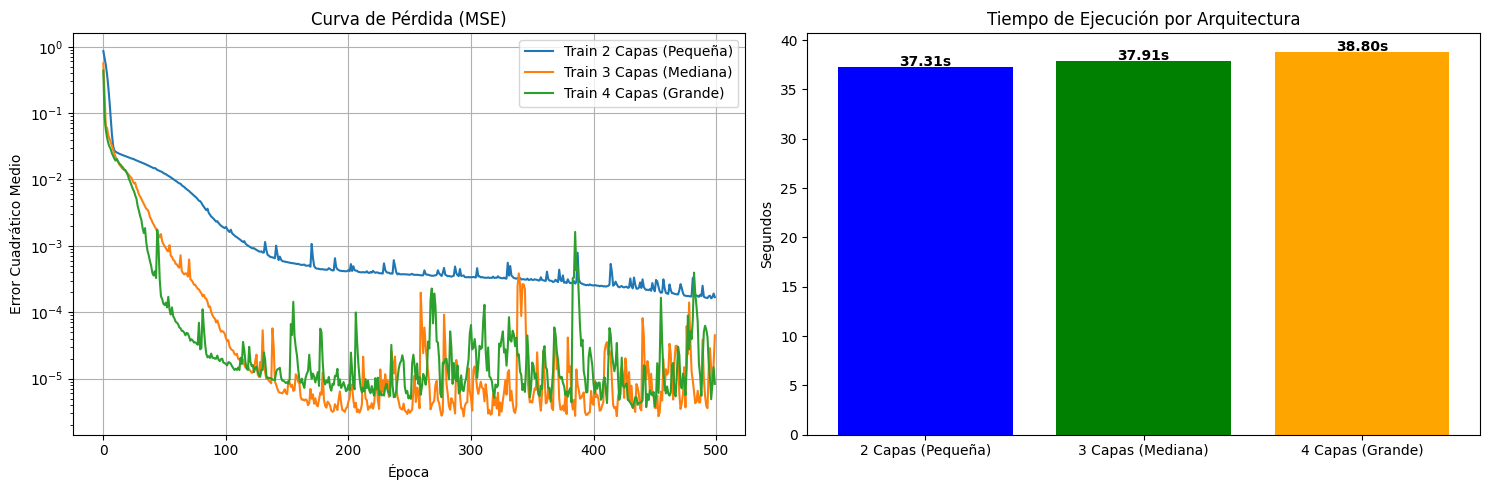

TypeError: 'float' object is not iterable

In [16]:
# Configuración de las gráficas
plt.figure(figsize=(15, 5))

# Gráfica 1: Pérdida (MSE) durante el entrenamiento
plt.subplot(1, 2, 1)
for i in range(len(historiales)):
    plt.plot(historiales[i].history['loss'], label=f'Train {nombres[i]}')
plt.title('Curva de Pérdida (MSE)')
plt.xlabel('Época')
plt.ylabel('Error Cuadrático Medio')
plt.legend()
plt.grid(True)

# Gráfica 2: Tiempos de ejecución
plt.subplot(1, 2, 2)
plt.bar(nombres, tiempos, color=['blue', 'green', 'orange'])
plt.title('Tiempo de Ejecución por Arquitectura')
plt.ylabel('Segundos')
for i, v in enumerate(tiempos):
    plt.text(i, v + 0.1, f"{v:.2f}s", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Configuración de las gráficas
plt.figure(figsize=(15, 5))

# Gráfica 1: Pérdida (MSE) durante el entrenamiento
plt.subplot(1, 2, 1)
for i in range(len(historiales)):
    plt.plot(historiales[i].history['loss'], label=f'Train {nombres[i]}')
plt.title('Curva de Pérdida (MSE)')
plt.xlabel('Época')
plt.ylabel('Error Cuadrático Medio')
plt.yscale('log') # Escala logarítmica para ver mejor la diferencia
plt.legend()
plt.grid(True)

# Gráfica 2: Tiempos de ejecución
plt.subplot(1, 2, 2)
plt.bar(nombres, tiempos, color=['blue', 'green', 'orange'])
plt.title('Tiempo de Ejecución por Arquitectura')
plt.ylabel('Segundos')
for i, v_val in enumerate(tiempos):
    plt.text(i, v_val + 0.05, f"{v_val:.2f}s", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()


X_plot = np.linspace(min(t), max(t), 100).reshape(-1, 1)
# -------------------------------------------

# Gráfica de Predicciones Finales
plt.figure(figsize=(10, 6))

# Graficamos los datos originales (usando los arrays que cargamos en X e y para evitar el error de dimensión)
plt.scatter(scaler_X.inverse_transform(X_scaled), 
            scaler_y.inverse_transform(y_scaled), 
            color='gray', alpha=0.3, label='Datos de entrenamiento', s=10)

for i in range(len(modelos)):
    # Predecir sobre el rango completo de tiempo
    X_nuevo_scaled = scaler_X.transform(X_plot)
    y_pred_scaled = modelos[i].predict(X_nuevo_scaled, verbose=0)
    y_pred = scaler_y.inverse_transform(y_pred_scaled)
    
    plt.plot(X_plot, y_pred, label=f'Predicción {nombres[i]}', linewidth=2)

plt.title('Comparación de Predicciones vs Datos Reales')
plt.xlabel('Tiempo (s)')
plt.ylabel('Velocidad (m/s)')
plt.legend()
plt.grid(True)
plt.show()

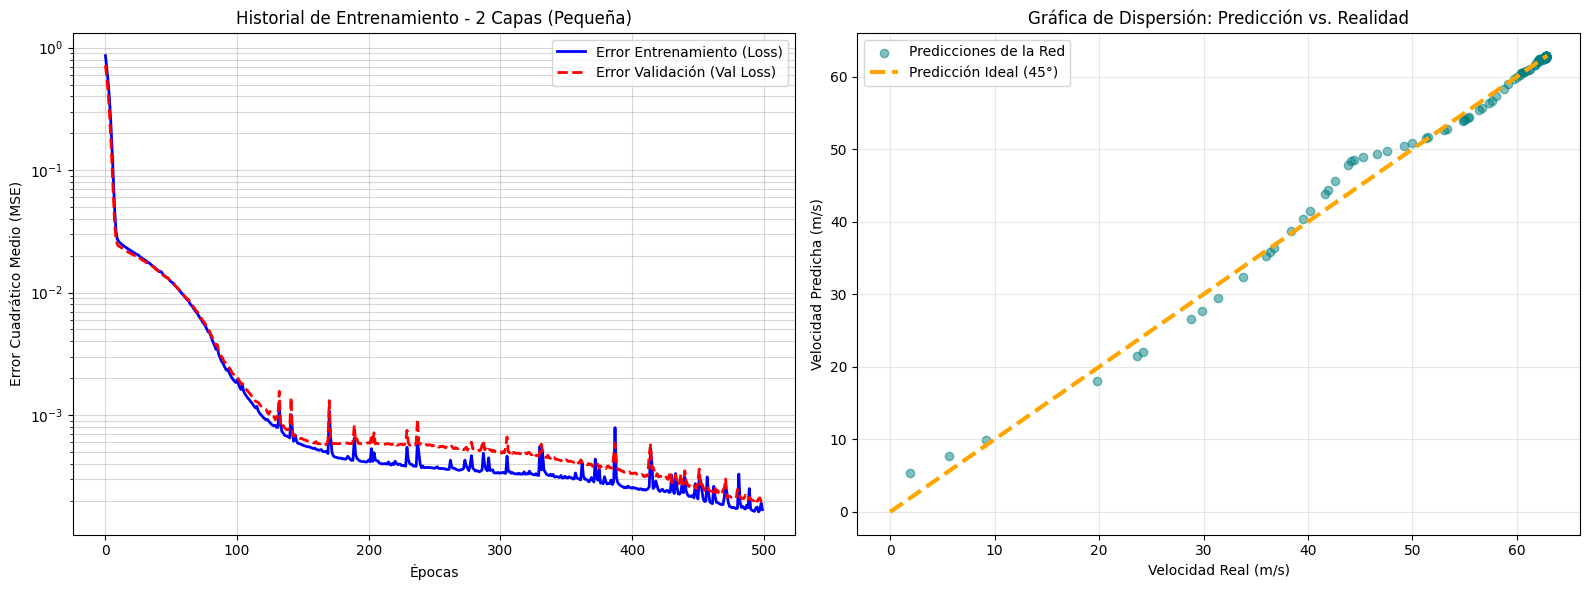

In [17]:
import matplotlib.pyplot as plt

modelo_a_graficar = modelos[0] 
nombre_modelo = nombres[0]
historial = historiales[0]

plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
plt.plot(historial.history['loss'], label='Error Entrenamiento (Loss)', color='blue', linewidth=2)
plt.plot(historial.history['val_loss'], label='Error Validación (Val Loss)', color='red', linestyle='--', linewidth=2)
plt.title(f'Historial de Entrenamiento - {nombre_modelo}')
plt.xlabel('Épocas')
plt.ylabel('Error Cuadrático Medio (MSE)')
plt.yscale('log')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.5)

plt.subplot(1, 2, 2)
y_pred_scaled = modelo_a_graficar.predict(X_test, verbose=0)
y_real_inv = scaler_y.inverse_transform(y_test)
y_pred_inv = scaler_y.inverse_transform(y_pred_scaled)
plt.scatter(y_real_inv, y_pred_inv, alpha=0.5, color='teal', label='Predicciones de la Red')
lims = [0, max(y_real_inv.max(), y_pred_inv.max())]
plt.plot(lims, lims, color='orange', linestyle='--', linewidth=3, label='Predicción Ideal (45°)')
plt.title('Gráfica de Dispersión: Predicción vs. Realidad')
plt.xlabel('Velocidad Real (m/s)')
plt.ylabel('Velocidad Predicha (m/s)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

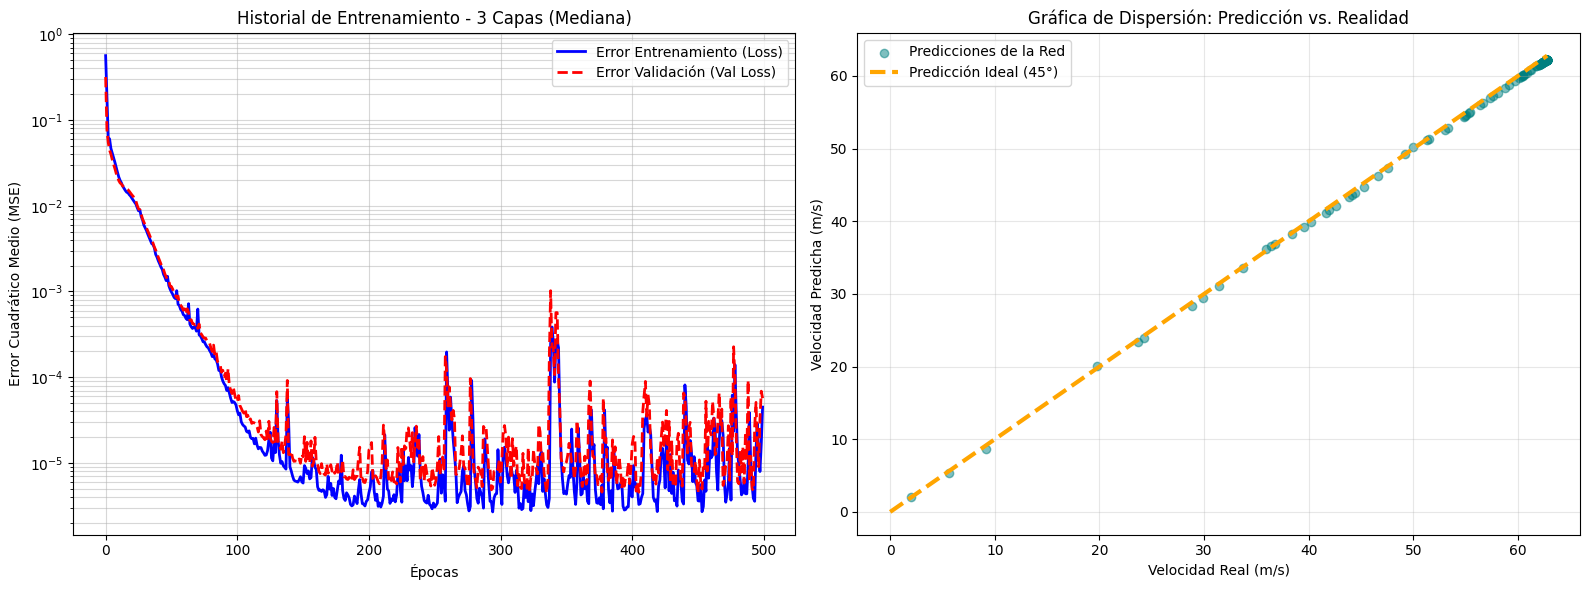

In [18]:
import matplotlib.pyplot as plt

modelo_a_graficar = modelos[1] 
nombre_modelo = nombres[1]
historial = historiales[1]

plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
plt.plot(historial.history['loss'], label='Error Entrenamiento (Loss)', color='blue', linewidth=2)
plt.plot(historial.history['val_loss'], label='Error Validación (Val Loss)', color='red', linestyle='--', linewidth=2)
plt.title(f'Historial de Entrenamiento - {nombre_modelo}')
plt.xlabel('Épocas')
plt.ylabel('Error Cuadrático Medio (MSE)')
plt.yscale('log')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.5)

plt.subplot(1, 2, 2)
y_pred_scaled = modelo_a_graficar.predict(X_test, verbose=0)
y_real_inv = scaler_y.inverse_transform(y_test)
y_pred_inv = scaler_y.inverse_transform(y_pred_scaled)
plt.scatter(y_real_inv, y_pred_inv, alpha=0.5, color='teal', label='Predicciones de la Red')
lims = [0, max(y_real_inv.max(), y_pred_inv.max())]
plt.plot(lims, lims, color='orange', linestyle='--', linewidth=3, label='Predicción Ideal (45°)')
plt.title('Gráfica de Dispersión: Predicción vs. Realidad')
plt.xlabel('Velocidad Real (m/s)')
plt.ylabel('Velocidad Predicha (m/s)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

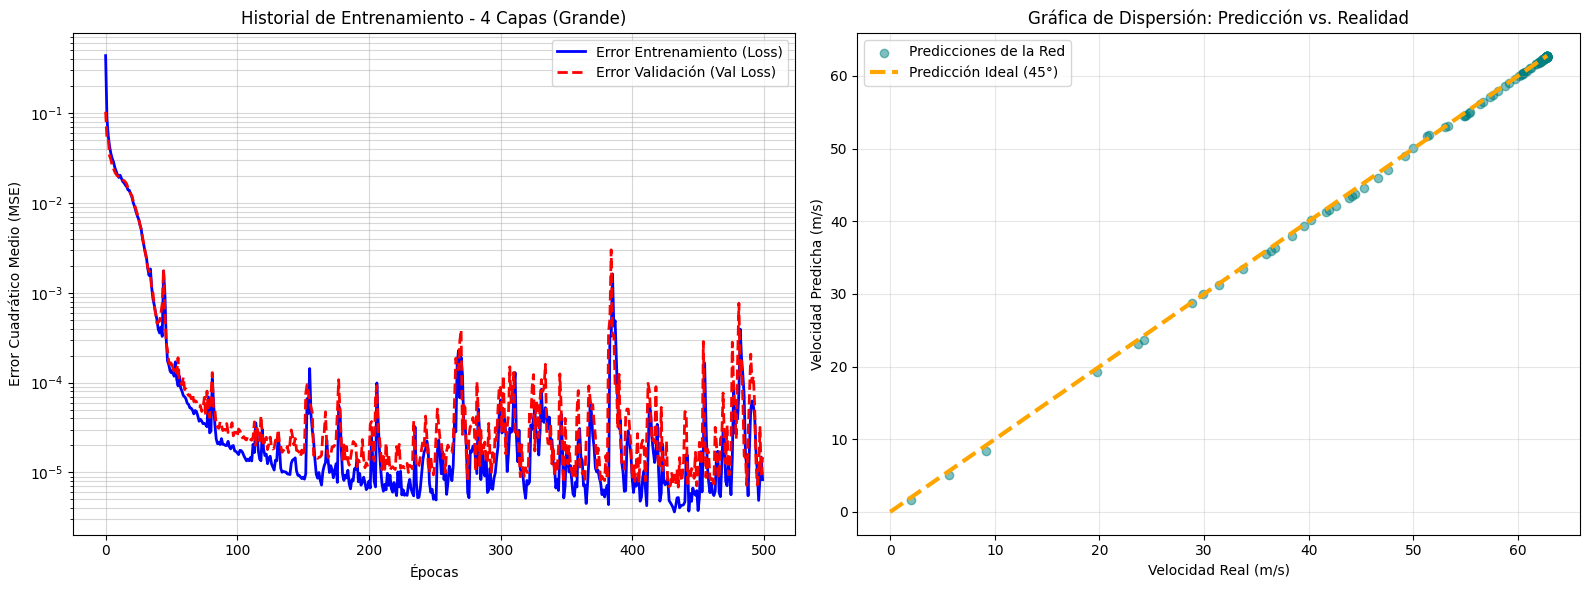

In [19]:
import matplotlib.pyplot as plt

modelo_a_graficar = modelos[2] 
nombre_modelo = nombres[2]
historial = historiales[2]

plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
plt.plot(historial.history['loss'], label='Error Entrenamiento (Loss)', color='blue', linewidth=2)
plt.plot(historial.history['val_loss'], label='Error Validación (Val Loss)', color='red', linestyle='--', linewidth=2)
plt.title(f'Historial de Entrenamiento - {nombre_modelo}')
plt.xlabel('Épocas')
plt.ylabel('Error Cuadrático Medio (MSE)')
plt.yscale('log')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.5)

plt.subplot(1, 2, 2)
y_pred_scaled = modelo_a_graficar.predict(X_test, verbose=0)
y_real_inv = scaler_y.inverse_transform(y_test)
y_pred_inv = scaler_y.inverse_transform(y_pred_scaled)
plt.scatter(y_real_inv, y_pred_inv, alpha=0.5, color='teal', label='Predicciones de la Red')
lims = [0, max(y_real_inv.max(), y_pred_inv.max())]
plt.plot(lims, lims, color='orange', linestyle='--', linewidth=3, label='Predicción Ideal (45°)')
plt.title('Gráfica de Dispersión: Predicción vs. Realidad')
plt.xlabel('Velocidad Real (m/s)')
plt.ylabel('Velocidad Predicha (m/s)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Conclusiones

**Arquitecturas:** Aumentar el número de capas mejora los resultados hasta cierto punto. El Modelo Mediano fue suficiente para capturar el comportamiento del sistema, y el Modelo Grande no aportó una mejora significativa que justificara su mayor costo computacional.

**Learning Rate:** Usar un valor muy alto hace que el entrenamiento sea inestable, mientras que uno muy bajo lo hace innecesariamente lento. El valor de `0.001` funcionó bien para este problema siendo el mejor balance entre velocidad y estabilidad.

**Early Stopping:** Permitió que los modelos dejaran de entrenar en el momento justo, sin desperdiciar tiempo ni deteriorar los resultados. El Modelo Pequeño fue el único que no se benefició de esta técnica ya que nunca alcanzó un nivel de precisión suficiente.

**Optimizadores:** Entre los tres probados, Adam fue el más efectivo llegando a los mejores resultados en el menor tiempo. SGD y RMSprop con el mismo learning rate no lograron igualar su desempeño.